# Classificador Naive Bayes

## Autores

| Nome | nUSP |
| :--- | :--- |
| Débora da Silva Morais | 15615790 |
| Guilherme de Abreu Barreto | 12543033 |

## Introdução

Neste exercício damos continuidade a exploração de técnicas de classificação para o problema formulado no artigo de Zanfei et al., [Novel approach for burst detection in water distribution systems based on graph neural networks](https://www.sciencedirect.com/science/article/abs/pii/S2210670722004073). Desta vez exploramos a técnica [_Naive Bayes_](https://en.wikipedia.org/wiki/Naive_Bayes_classifier), cuja definição e aplicação descrevemos a seguir.

## Definição da técnica _Naive Bayes_

O Teorema de Bayes, é uma forma pela qual pode ser expressa a probabilidade de um evento futuro ocorrer dado algum conhecimento prévio acerca de circunstâncias nas quais este já ocorreu. Este é expresso matemáticamente da seguinte maneira:

$$
P(A \mid B) = \dfrac{P(B \mid A) \cdot P(A)}{P(B)}
$$

Onde $A$ e $B$ são eventos distintos. No contexto da nossa análise, tem-se:

- $A$ é a ocorrência de vazamento, e $P(A)$ a probabilidade _a priori_ desta ocorrer.
- $B$ é um estado dos parâmetros do modelo, e $P(B)$ a probabilidade _a priori_ destes assumirem tal estado.
- $P(A | B)$ é a probabilidade de $A$ ocorrer tido que $B$ já ocorreu (probabilidade _a posteriori_).
- $ P(B | A)$ é a probabilidade de $B$ ocorrer tido que $A$ já ocorreu (probabilidade _a priori_).

De maneira análoga, se decorreria para calcular a probabilidade para a não ocorrência de vazamento $P(\neg A \mid B)$. Assim sendo, o classificador _Naive Bayes_ avalia qual destes dois eventos é mais provável: a ocorrência do vazamento  $P(A \mid B)$ ou a não ocorrência do mesmo $P(\neg A \mid B)$.

### Calculo da probabilidade em variáveis discretas e contínuas

A ocorrência de vazamento trata-se de uma variável discreta que assume um de dois valores: verdadeiro ou falso. O cálculo da probabilidade absoluta de sua ocorrência _a priori_ é bastante direto:

$$
P(A) = \dfrac{|A|}{N}
$$

Sendo:

- $|A|$ o número de ocorrências de vazamento observadas.
- $N$ o número de observações feitas.

Agora, como todos os valores contidos no conjunto $B$ são contínuos, conforme aprendemos em nossas aulas de Estatística, a probabilidade absoluta de um número real assumir dado valor exato dado uma infinidade de $N$ valores possíveis é _infinitesimal_. O que podemos aferir, entretanto, é a _probabilidade relativa_ entre dados valores em uma distribuição. Ao assumirmos uma [Distribuição Gaussiana](https://en.wikipedia.org/wiki/Normal_distribution), esta probabilidade relativa pode ser aferida por meio da Função de Densidade de Probabilidade (FDP), expressa como:

$$
P(x) = \dfrac{1}{\sigma\sqrt{2\pi}} \cdot e^{- \dfrac{(x - \mu)^2}{2\sigma^2}}
$$

Sendo:

- $x$ o parâmetro para o qual estamos avaliando a probabilidade relativa.
- $\mu$ o valor médio para $x$
- $\sigma$ o desvio padrão da distribuição
- $\pi$ o número pi.
- $e$ o número de Euler.

Finalmente, como nosso conjunto $B$ contêm $n$ parâmetros $x$, $P(B)$ pose ser expresso por:

$$
P(B) = \prod^n_{i = 0} P(x_i)
$$

### Independência entre os parâmetros

A parte "Naive" (ingênuo) do nome do método _Naive Bayes_ remete a presunção de que os parâmetros em $B$ são todos _independentes entre si_. Dada nossa análise exploratória, sabemos que isso _não é verdade_ para nosso conjunto de dados: os valores de pressão e vazão exibem _elevados índices de correlação_. Não obstante, podemos aproveitar o uso desta técnica de aplicação relativamente simples para pautar o desempenho de técnicas mais avançadas como _Random Forests_ (Floresta Aleatória) ou _Support-Vector Machine_ (Máquina de Vetor Suporte)

### Limiar de decisão

Em conjuntos de dados cujas classes são altamente desbalanceadas, como é o nosso, convêm não aceitar apenas que a probabilidade de uma classe se sobressaia a outra, pois isso ocorre consistentemente, leva a muitos casos de classificação de _falsos negativos_ e um f1 score mais baixo. Tidas normalizada a probabilidades de um evento ocorrer ou não, convêm testar diferentes limiares de decisão a partir do qual uma dado evento é avaliado de diferentes formas. Em nosso experimento, testamos diferentes valores de probabilidade entre 0 e 1 para a classificação, em intervalos de 0.1.

## Definição da aplicação

### Dependências

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    cross_val_predict
)
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
)

### Constantes

A seguir são definidos os seguintes atributos:

- `SEED`: valor inteiro utilizado para cálculo de números pseudo-aleatórios. Assegura a reprodutibilidade do notebook em procedimentos probabilísticos como a geração pseudo-aleatória de divisões de treino e validação.

- `DATASETS_FOLDER` e `DATASETS`: Referem-se ao diretório e arquivos onde os dados de referência para este estudo estão localizados.

In [2]:
SEED = 42
DATASETS_FOLDER = '../generated-datasets-for-burst-detection-in-water-distribution-systems'
DATASETS = [f'{DATASETS_FOLDER}/WDts{i}/WDts{i}_dataset.csv' for i in range(1, 5)]

## Carregamento dos dados

A função abaixo carrega os dados a partir dos arquivos de referência, eliminando quaisquer registros em que a variável alvo não esteja presente e atribuindo um valor médio a quaisquer valores faltantes observados nos parâmetros.

In [3]:
def load_data(
    csv_path: str, features: list[str], target: str
) -> tuple[pd.DataFrame, ...]:
    df = pd.read_csv(
        csv_path,
        dtype={target: bool},
        index_col=False,
        sep=';',
    )
    df = df[df[target].notna()]
    df.info()
    return df[features].fillna(df[features].mean()), df[target]

## Implementação manual (não aproveitada)

Abaixo está descrita a implementação manual de um classicador Gausiano de _Naive Bayes_ que acabou por não ser utilizada em favor do classificador disponibilizado pela biblioteca [scikit learn](https://scikit-learn.org/stable/modules/naive_bayes.html#gaussian-naive-bayes). Em nossa implementação encontramos erros de precisão no cálculo de probabilidade (especificamente o [_underflow_ aritmético](https://en.wikipedia.org/wiki/Arithmetic_underflow) em casos com probabilidade muito baixa) que não foram resolvidos a tempo.

In [4]:
class Custom_GaussianNB:

    def __init__(self, X_train: pd.DataFrame, y_train: pd.Series) -> None:
        """
        Initializes and fits the model by calculating class priors, means,
        and standard deviations.

        Args:
            X_train (pd.DataFrame): The training features.
            y_train (pd.Series): The training labels.
        """

        # Extract classes and feature names
        self.feature_columns = X_train.columns.tolist()
        self.classes = y_train.unique()

        # Calculate log priors
        class_counts = y_train.value_counts()
        self.log_priors = {
            cls: np.log(class_counts[cls] / len(y_train)) for cls in self.classes
        }
        
        # Calcualte feature means and stds per class
        self.mean = {}
        self.std = {}
        for cls, group in X_train.groupby(y_train):
            self.mean[cls] = group.mean().to_dict()
            self.std[cls] = (group.std() + 1e-9).to_dict()


    # Generate probability predictions and classifications
    def __call__(
        self,
        X_test: pd.DataFrame,
        decision_thereshold: float = 0.5
    ) -> pd.DataFrame:
        """
        Generates probability predictions and classifications for the test set.

        Args:
            X_test (pd.DataFrame): The test features.
            decision_threshold (float): The probability threshold to classify an
                                        instance as 'True'. Defaults to 0.5.

        Returns:
            pd.DataFrame: Contains the normalized probability for the 'True'
                          class and the final classification.
        """

        # Initialize arrays to store the posterior log-probabilities for each class.
        # We start with the log-prioes, which are constants for all samples.
        n_samples = len(X_test)
        log_posteriors = {
            cls: np.full(n_samples, self.log_priors[cls]) for cls in self.classes
        }

        # Add the log-likelihoods for each feature in a vectorized manner
        for feature in self.feature_columns:
            x = X_test[feature].values
            for cls in self.classes:
                log_posteriors[cls] += self._log_gaussian_pdf(
                    x,
                    self.mean[cls][feature],
                    self.std[cls][feature]
                )

        # Normalize probabilities and classify
        max_log = np.maximum(log_posteriors[True], log_posteriors[False])
        exp_true = np.exp(log_posteriors[True] - max_log)
        exp_false = np.exp(log_posteriors[False] - max_log)

        normalized_true_prob = exp_true / (exp_true + exp_false)

        # Apply decision thereshold to the final, normalized probability
        return pd.DataFrame({
            'normalized_true_prob': normalized_true_prob,
            'classification': log_posteriors[True] > log_posteriors[False]
        }, index=X_test.index)

        

    @staticmethod
    def _log_gaussian_pdf(x: float, mean: float, std: float) -> float:
        """
        Calculates the log of the Gaussian Probability Density Function (PDF).

        The formula is: log(PDF) = -log(σ√(2π)) - ((x - μ)² / (2σ²))
        """
        coefficient =  - np.log(std * np.sqrt(2 * np.pi))
        exponent = - ((x - mean) ** 2) / (2 * std ** 2)
        return coefficient * np.exp(exponent)        

## Avaliação do modelo

Avaliamos nosso modelo usando um gráfico de linha f1 score versus limiar de decisão: este indica limiar de decisão ótimo conforme esta métrica de avaliação, a qual detalhamos em exercício anteiror. Para o valor de f1 ótimo, também imprimimos uma matriz de confusão e sua Curva ROC.

In [5]:
def evaluate(
    prob_scores: pd.Series,
    actual: pd.Series,
    testset_name: str
) -> None:
    thresholds = np.arange(0.0, 1.01, 0.01)
    f1_scores = [
        f1_score(actual, prob_scores >= t) for t in thresholds
    ]

    best_f1_index = np.argmax(f1_scores)
    best_threshold = thresholds[best_f1_index]
    best_f1_score = f1_scores[best_f1_index]

    # Plot the F1 score vs. Threshold graph
    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, f1_scores, label='F1 Score')
    plt.axvline(
        x=best_threshold, color='r', linestyle='--',
        label=f'Melhor limiar de decisão ({best_threshold:.2f})'
    )
    plt.title(f'F1 Score vs. limiar de decisão - Teste {testset_name}')
    plt.xlabel('Limiar de decisão')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    classifications = prob_scores >= best_threshold

    # Print Confusion Matrix
    cm = confusion_matrix(actual, classifications)
    cm_percentage = cm.astype('float') /cm.sum(axis=1)[:, np.newaxis] * 100
    plt.figure(figsize=(8,6))
    labels = ["Falso", "Verdadeiro"]
    sns.heatmap(
        cm_percentage,
        annot=True,
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        fmt='.2f'
    )
    plt.xlabel('Previsão')
    plt.ylabel('Realidade')
    plt.title(f"Matriz de Confusão (Limiar de decisão = {best_threshold}), Teste {testset_name}")
    plt.show

    # Plot ROC Curve
    fpr, tpr, thresholds = roc_curve(actual, prob_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(10, 8))
    plt.plot(
        fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})'
    )
    plt.plot(
        [0, 1],
        [0, 1],
        color='navy',
        lw=2,
        linestyle='--',
        label='Classificador aleatório'
    )
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taxa de falsos positivos')
    plt.ylabel('Taxa de positivos verdadeiros')
    plt.title(f'Curva ROC, conjunto de teste {testset_name}')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()
        

### Pipeline

In [6]:
def gaussian_nb_pipeline(csv_path: str) -> None:
    skf = StratifiedKFold(5, shuffle=True, random_state=SEED)
    target = 'burst'
    features = [
        f'flow_meter{i}' for i in range(1, 5)
    ] + [
        f'{i}_press' for i in [3, 12, 36, 50, 60, 84, 93, 112, 138, 139]
    ]
    X, y = load_data(csv_path, features, target)
    gnb = GaussianNB()
    probabilities = cross_val_predict(gnb, X, y, cv=skf, method='predict_proba')[:, 1]
    evaluate(
        pd.Series(probabilities, index = y.index),
        y,
        csv_path.rsplit('/', 1)[-1],
    )

## Aplicações

### Conjunto WDts1

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   index        35040 non-null  object 
 1   burst        35040 non-null  bool   
 2   flow_meter1  35040 non-null  float64
 3   flow_meter2  35040 non-null  float64
 4   flow_meter3  35040 non-null  float64
 5   flow_meter4  35040 non-null  float64
 6   3_press      35040 non-null  float64
 7   12_press     35040 non-null  float64
 8   36_press     35040 non-null  float64
 9   50_press     35040 non-null  float64
 10  60_press     35040 non-null  float64
 11  84_press     35040 non-null  float64
 12  93_press     35040 non-null  float64
 13  112_press    35040 non-null  float64
 14  138_press    35040 non-null  float64
 15  139_press    35040 non-null  float64
dtypes: bool(1), float64(14), object(1)
memory usage: 4.0+ MB


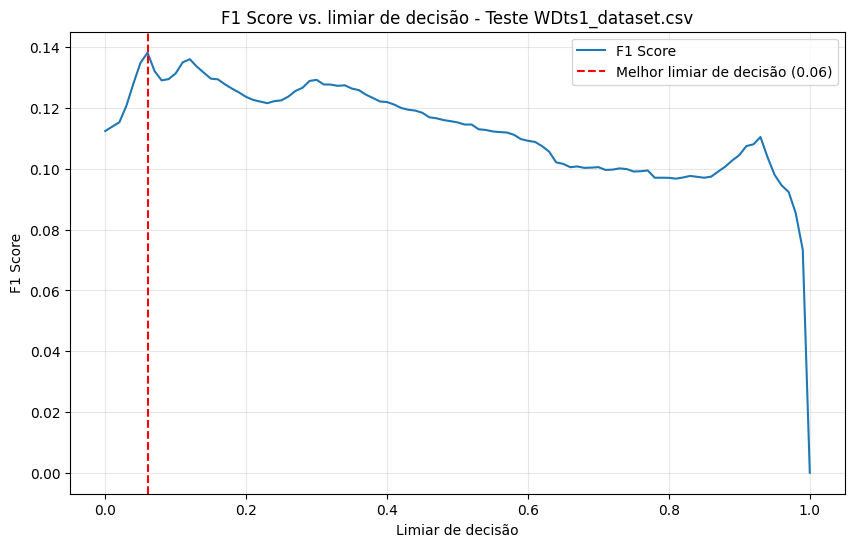

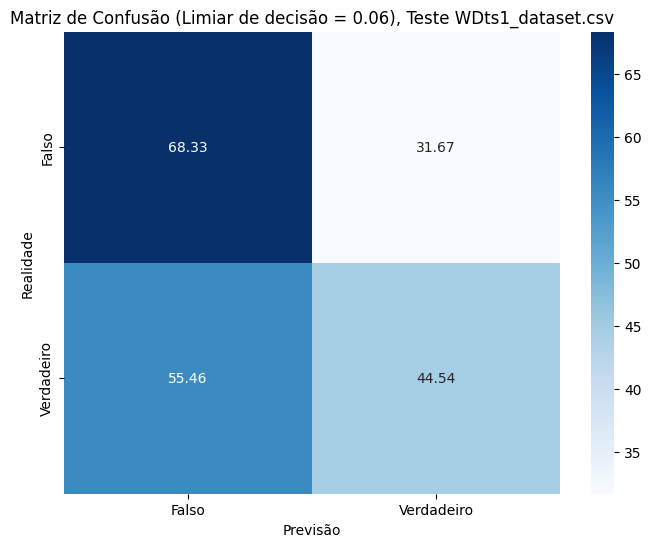

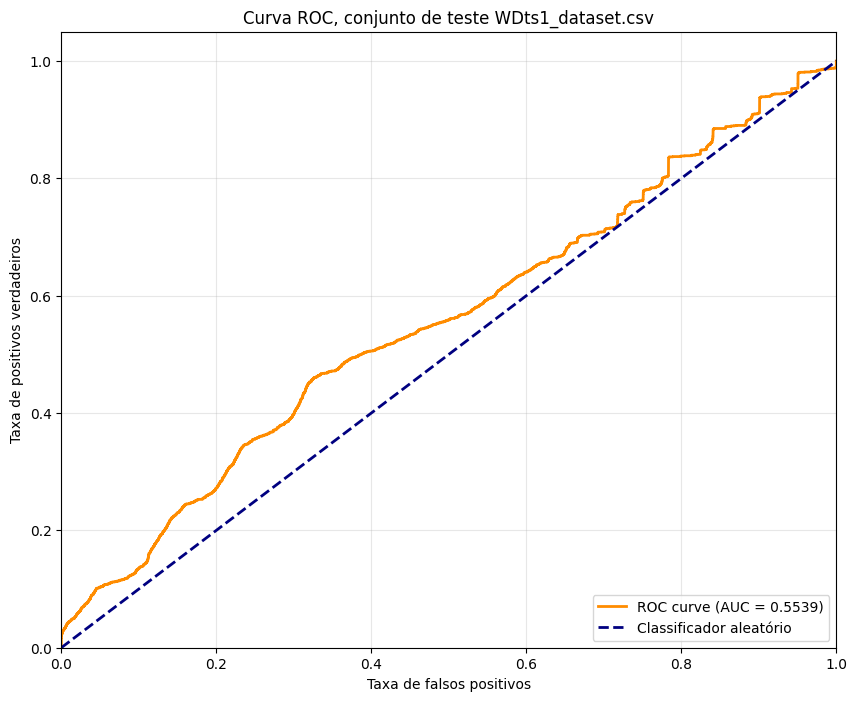

In [7]:
gaussian_nb_pipeline(DATASETS[0])

### Conjunto WDts2

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   index        35040 non-null  object 
 1   burst        35040 non-null  bool   
 2   flow_meter1  35040 non-null  float64
 3   flow_meter2  35040 non-null  float64
 4   flow_meter3  35040 non-null  float64
 5   flow_meter4  35040 non-null  float64
 6   3_press      35040 non-null  float64
 7   12_press     35040 non-null  float64
 8   36_press     35040 non-null  float64
 9   50_press     35040 non-null  float64
 10  60_press     35040 non-null  float64
 11  84_press     35040 non-null  float64
 12  93_press     35040 non-null  float64
 13  112_press    35040 non-null  float64
 14  138_press    35040 non-null  float64
 15  139_press    35040 non-null  float64
dtypes: bool(1), float64(14), object(1)
memory usage: 4.0+ MB


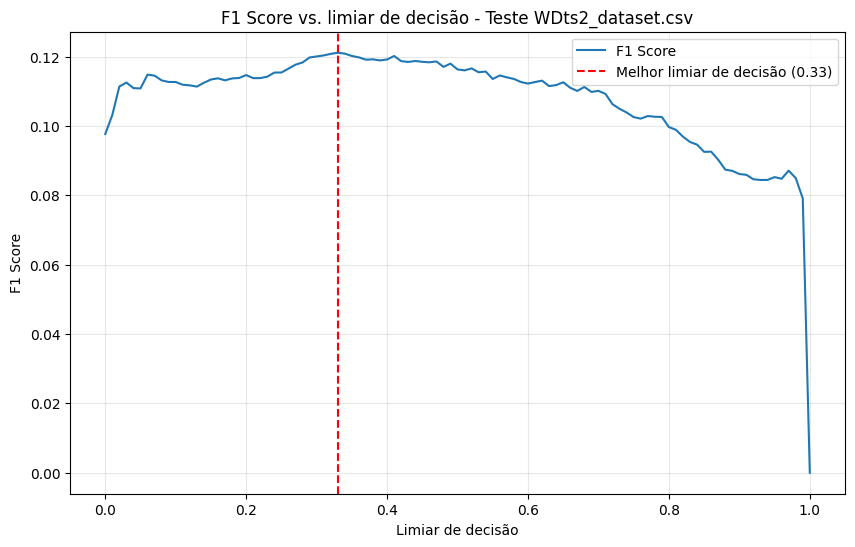

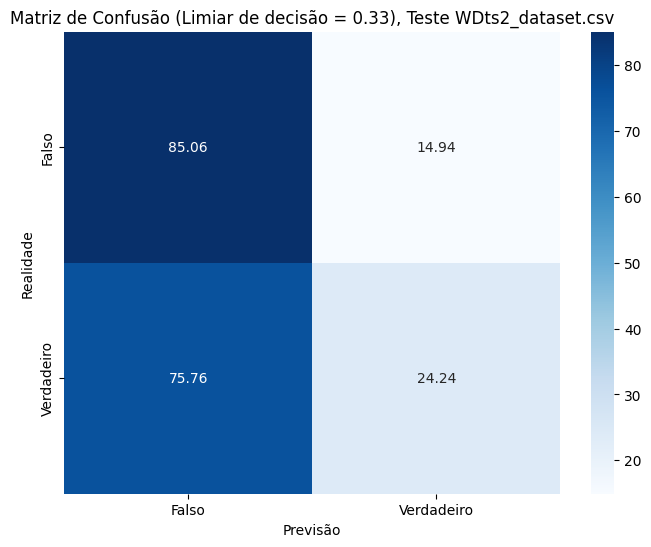

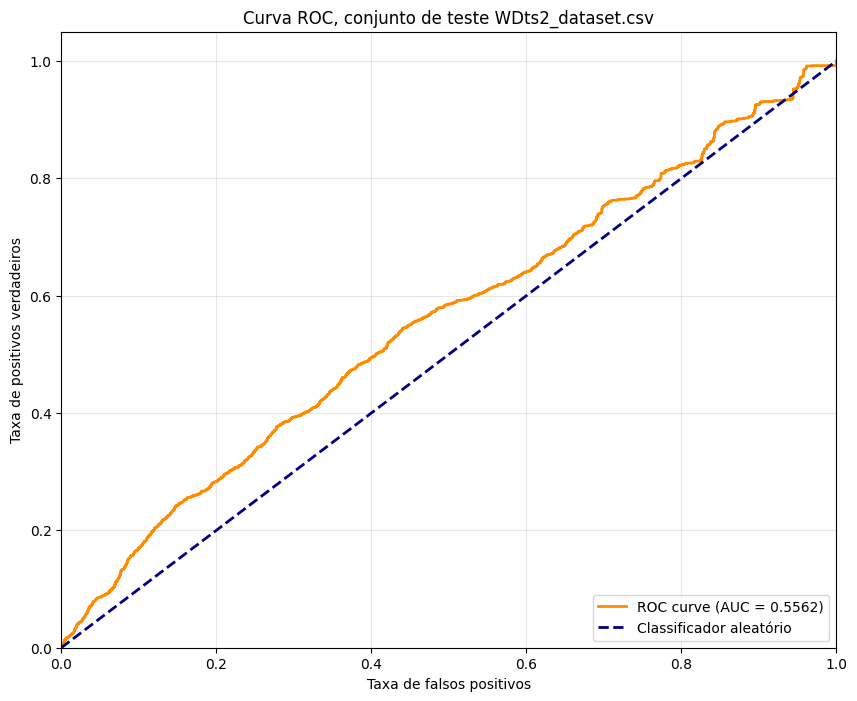

In [8]:
gaussian_nb_pipeline(DATASETS[1])

### Conjunto WDts3

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   index        35040 non-null  object 
 1   burst        35040 non-null  bool   
 2   flow_meter1  35040 non-null  float64
 3   flow_meter2  35040 non-null  float64
 4   flow_meter3  35040 non-null  float64
 5   flow_meter4  35040 non-null  float64
 6   3_press      35040 non-null  float64
 7   12_press     35040 non-null  float64
 8   36_press     35040 non-null  float64
 9   50_press     35040 non-null  float64
 10  60_press     35040 non-null  float64
 11  84_press     35040 non-null  float64
 12  93_press     35040 non-null  float64
 13  112_press    35040 non-null  float64
 14  138_press    35040 non-null  float64
 15  139_press    35040 non-null  float64
dtypes: bool(1), float64(14), object(1)
memory usage: 4.0+ MB


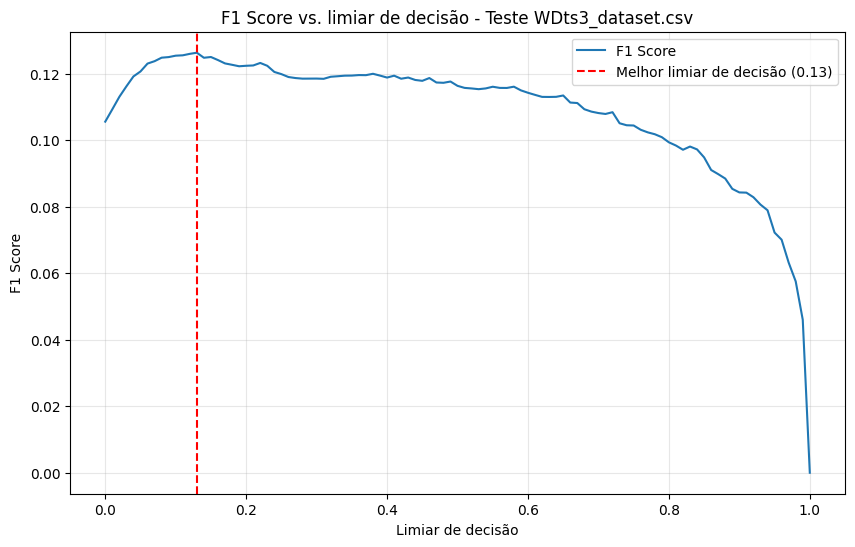

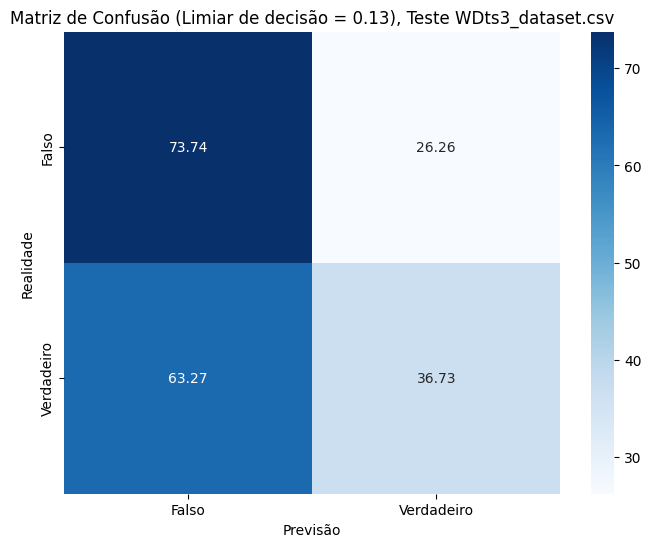

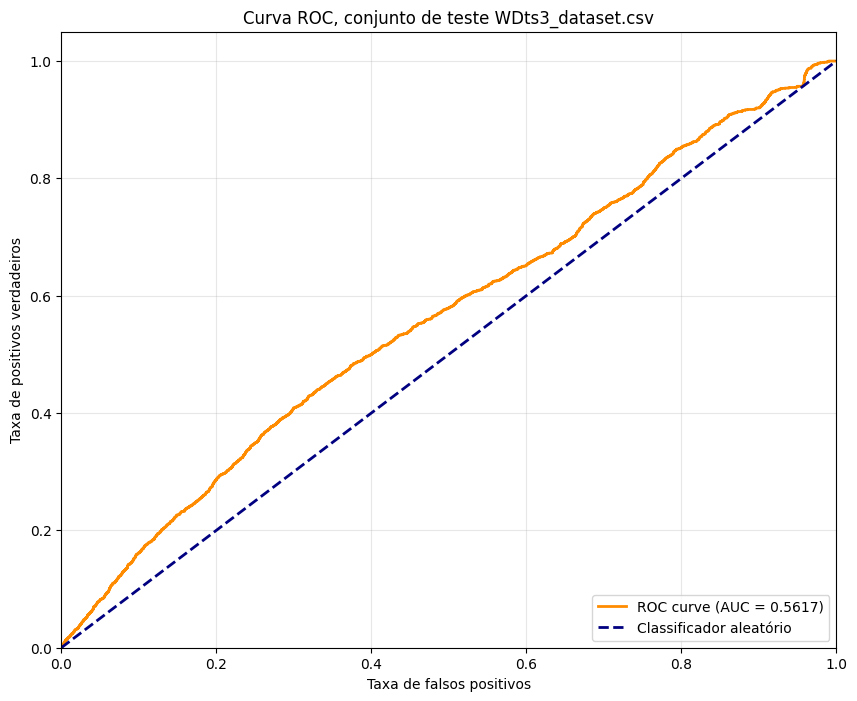

In [9]:
gaussian_nb_pipeline(DATASETS[2])

### Conjunto WDts4

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   index        35040 non-null  object 
 1   burst        35040 non-null  bool   
 2   flow_meter1  35040 non-null  float64
 3   flow_meter2  35040 non-null  float64
 4   flow_meter3  35040 non-null  float64
 5   flow_meter4  35040 non-null  float64
 6   3_press      35040 non-null  float64
 7   12_press     35040 non-null  float64
 8   36_press     35040 non-null  float64
 9   50_press     35040 non-null  float64
 10  60_press     35040 non-null  float64
 11  84_press     35040 non-null  float64
 12  93_press     35040 non-null  float64
 13  112_press    35040 non-null  float64
 14  138_press    35040 non-null  float64
 15  139_press    35040 non-null  float64
dtypes: bool(1), float64(14), object(1)
memory usage: 4.0+ MB


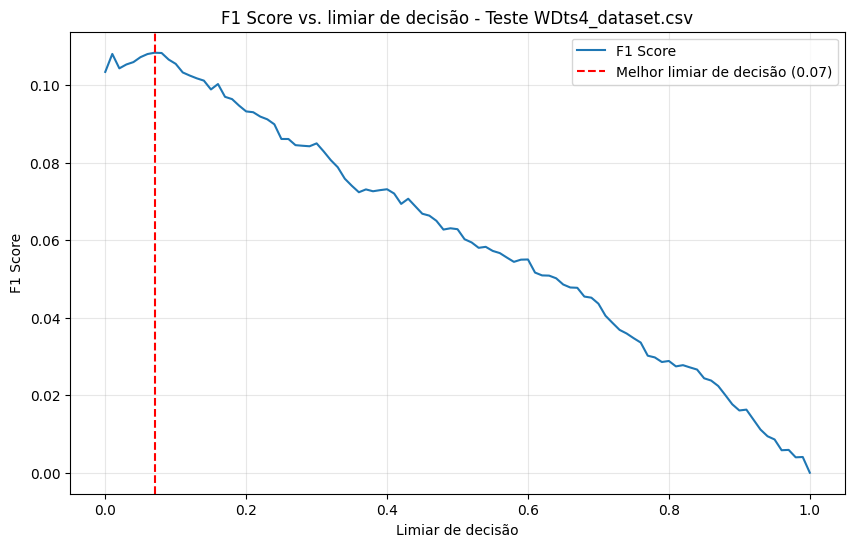

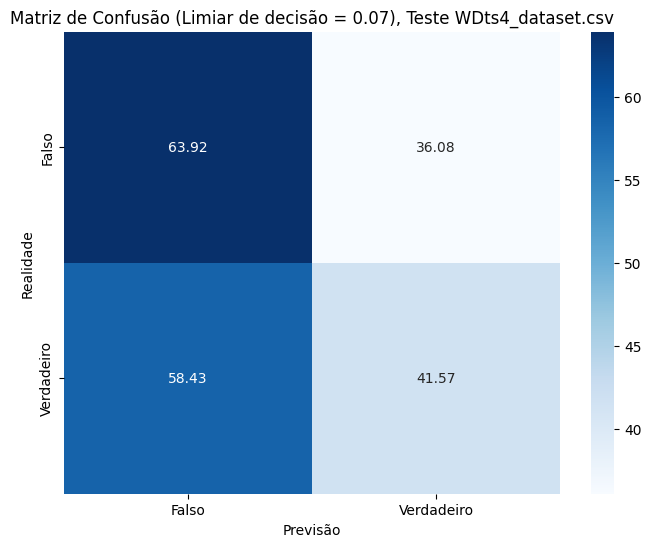

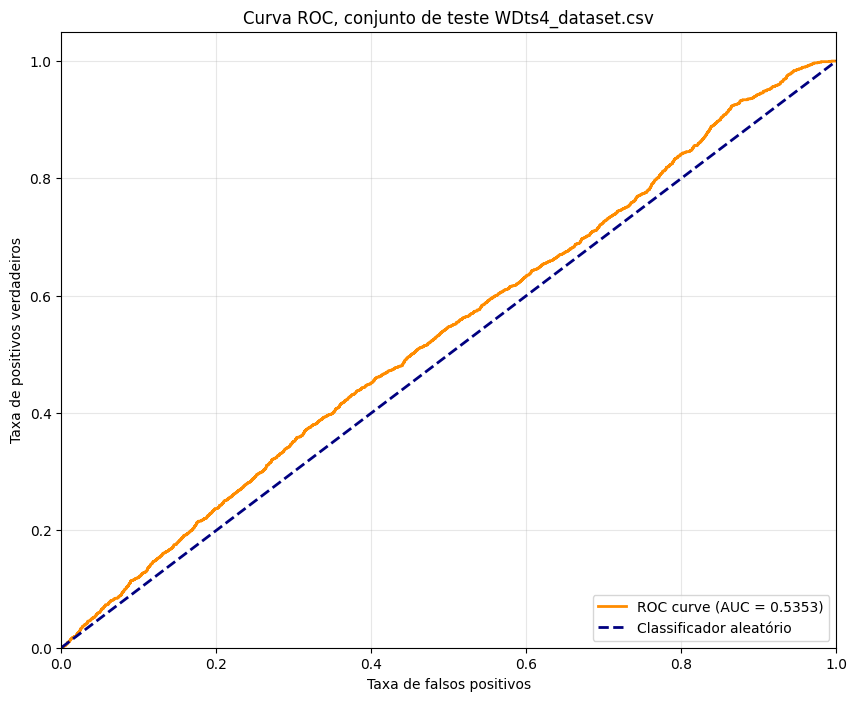

In [10]:
gaussian_nb_pipeline(DATASETS[3])

## Principais achados

Foram aspectos positivos da aplicação do método Naive Bayes em nossa análise:

- A simplicidade do algoritmo e do ajuste de seus hiperparâmetros: tivemos apenas de ajustar o limiar de decisão em que a probabilidade do vazamento ocorrer implica uma classificação positiva. Dada a raridade deste evento, valores baixos de probabilidade apresentaram os melhores resultados.

- A rapidez, quase instantânea, com que o algoritmo é executado. Ainda que os resultados apresentados não houvessem sido precisos, este é um algoritmo que, como pouco recursos, pode ser utilizado para pautar o desempenho de algoritmos mais avançados.

Enquanto foram aspectos negativos:

- O pior desempenho, se comparado a Árvore de Decisão, considerando a métrica f1.